In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/passengers data.csv")


In [19]:
# exploring the dataset

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [5]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


In [6]:
df.shape

(418, 12)

In [7]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [20]:
# finding and handling the missing values

In [8]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [10]:
df["Age"] = df["Age"].fillna(df["Age"].mean())

In [11]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [12]:
df["Cabin"] = df["Cabin"].fillna("Unknown")

In [21]:
# removing duplicate records
df.drop_duplicates(inplace=True)

In [22]:
# identifying and treating the outliers

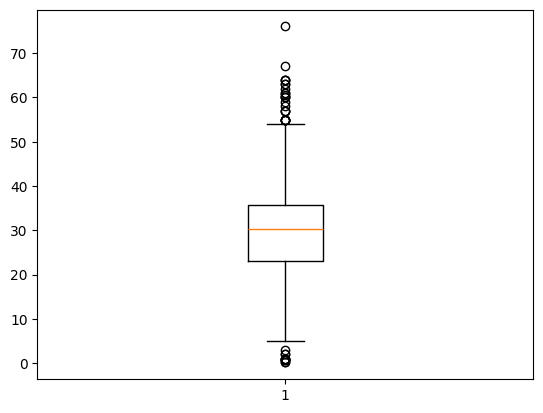

In [14]:
plt.boxplot(df["Age"])
plt.show()

In [15]:
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["Age"] >= lower) & (df["Age"] <= upper)]

In [23]:
# filtering the data

In [16]:
df[df["Age"] > 30]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.50000,0,0,330911,7.8292,Unknown,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.00000,1,0,363272,7.0000,Unknown,S
10,902,0,3,"Ilieff, Mr. Ylio",male,30.27259,0,0,349220,7.8958,Unknown,S
11,903,0,1,"Jones, Mr. Charles Cresson",male,46.00000,0,0,694,26.0000,Unknown,S
14,906,1,1,"Chaffee, Mrs. Herbert Fuller (Carrie Constance...",female,47.00000,1,0,W.E.P. 5734,61.1750,E31,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,30.27259,0,0,A.5. 3236,8.0500,Unknown,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.00000,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.50000,0,0,SOTON/O.Q. 3101262,7.2500,Unknown,S
416,1308,0,3,"Ware, Mr. Frederick",male,30.27259,0,0,359309,8.0500,Unknown,S


In [17]:
df[df["Sex"] == "female"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.00000,1,0,363272,7.0000,Unknown,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.00000,1,1,3101298,12.2875,Unknown,S
6,898,1,3,"Connolly, Miss. Kate",female,30.00000,0,0,330972,7.6292,Unknown,Q
8,900,1,3,"Abrahim, Mrs. Joseph (Sophie Halaut Easu)",female,18.00000,0,0,2657,7.2292,Unknown,C
12,904,1,1,"Snyder, Mrs. John Pillsbury (Nelle Stevenson)",female,23.00000,1,0,21228,82.2667,B45,S
...,...,...,...,...,...,...,...,...,...,...,...,...
408,1300,1,3,"Riordan, Miss. Johanna Hannah""""",female,30.27259,0,0,334915,7.7208,Unknown,Q
410,1302,1,3,"Naughton, Miss. Hannah",female,30.27259,0,0,365237,7.7500,Unknown,Q
411,1303,1,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.00000,1,0,19928,90.0000,C78,Q
412,1304,1,3,"Henriksson, Miss. Jenny Lovisa",female,28.00000,0,0,347086,7.7750,Unknown,S


In [18]:
df[df["Pclass"] == 1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
11,903,0,1,"Jones, Mr. Charles Cresson",male,46.00000,0,0,694,26.0000,Unknown,S
12,904,1,1,"Snyder, Mrs. John Pillsbury (Nelle Stevenson)",female,23.00000,1,0,21228,82.2667,B45,S
14,906,1,1,"Chaffee, Mrs. Herbert Fuller (Carrie Constance...",female,47.00000,1,0,W.E.P. 5734,61.1750,E31,S
22,914,1,1,"Flegenheim, Mrs. Alfred (Antoinette)",female,30.27259,0,0,PC 17598,31.6833,Unknown,S
23,915,0,1,"Williams, Mr. Richard Norris II",male,21.00000,0,1,PC 17597,61.3792,Unknown,C
...,...,...,...,...,...,...,...,...,...,...,...,...
403,1295,0,1,"Carrau, Mr. Jose Pedro",male,17.00000,0,0,113059,47.1000,Unknown,S
404,1296,0,1,"Frauenthal, Mr. Isaac Gerald",male,43.00000,1,0,17765,27.7208,D40,C
407,1299,0,1,"Widener, Mr. George Dunton",male,50.00000,1,1,113503,211.5000,C80,C
411,1303,1,1,"Minahan, Mrs. William Edward (Lillian E Thorpe)",female,37.00000,1,0,19928,90.0000,C78,Q


In [24]:
# sorting the data

In [25]:
df.sort_values("Age")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
379,1271,0,3,"Asplund, Master. Carl Edgar",male,5.0,4,2,347077,31.3875,Unknown,S
389,1281,0,3,"Palsson, Master. Paul Folke",male,6.0,3,1,349909,21.0750,Unknown,S
80,972,0,3,"Boulos, Master. Akar",male,6.0,1,1,2678,15.2458,Unknown,C
196,1088,0,1,"Spedden, Master. Robert Douglas",male,6.0,0,2,16966,134.5000,E34,C
161,1053,0,3,"Touma, Master. Georges Youssef",male,7.0,1,1,2650,15.2458,Unknown,C
...,...,...,...,...,...,...,...,...,...,...,...,...
293,1185,0,1,"Dodge, Dr. Washington",male,53.0,1,1,33638,81.8583,A34,S
224,1116,1,1,"Candee, Mrs. Edward (Helen Churchill Hungerford)",female,53.0,0,0,PC 17606,27.4458,Unknown,C
131,1023,0,1,"Gracie, Col. Archibald IV",male,53.0,0,0,113780,28.5000,C51,C
177,1069,0,1,"Stengel, Mr. Charles Emil Henry",male,54.0,1,0,11778,55.4417,C116,C


In [26]:
df.sort_values("Fare", ascending=False)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
53,945,1,1,"Fortune, Miss. Ethel Flora",female,28.00000,3,2,19950,263.0000,C23 C25 C27,S
375,1267,1,1,"Bowen, Miss. Grace Scott",female,45.00000,0,0,PC 17608,262.3750,Unknown,C
24,916,1,1,"Ryerson, Mrs. Arthur Larned (Emily Maria Borie)",female,48.00000,1,3,PC 17608,262.3750,B57 B59 B63 B66,C
59,951,1,1,"Chaudanson, Miss. Victorine",female,36.00000,0,0,PC 17608,262.3750,B61,C
64,956,0,1,"Ryerson, Master. John Borie",male,13.00000,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
...,...,...,...,...,...,...,...,...,...,...,...,...
133,1025,0,3,"Thomas, Mr. Charles P",male,30.27259,1,0,2621,6.4375,Unknown,C
116,1008,0,3,"Thomas, Mr. John",male,30.27259,0,0,2681,6.4375,Unknown,C
21,913,0,3,"Olsen, Master. Artur Karl",male,9.00000,0,1,C 17368,3.1708,Unknown,S
266,1158,0,1,"Chisholm, Mr. Roderick Robert Crispin",male,30.27259,0,0,112051,0.0000,Unknown,S


In [27]:
# grouping the data

In [28]:
df.groupby("Pclass")["Age"].mean()

,Age
Pclass,
1,35.709697
2,27.963094
3,26.880988


In [29]:
df.groupby("Survived")["PassengerId"].count()

,PassengerId
Survived,
0,249
1,133


In [30]:
df.groupby("Sex")["Fare"].mean()

,Fare
Sex,
female,44.213410
male,24.496519


In [31]:
# statistical calculations


In [32]:
df["Survived"].value_counts()

,count
Survived,
0,249
1,133


In [33]:
df["Survived"].mean()

np.float64(0.3481675392670157)

In [34]:
print(df["Age"].mean())

29.15560934838832


In [35]:
print(df["Age"].median())

30.272590361445783


In [36]:
print(df["Age"].mode())

0    30.27259
Name: Age, dtype: float64


In [37]:
print(df["Age"].var())

89.01187917253816


In [38]:
print(df["Age"].std())

9.434610705934727


In [39]:
# visualization

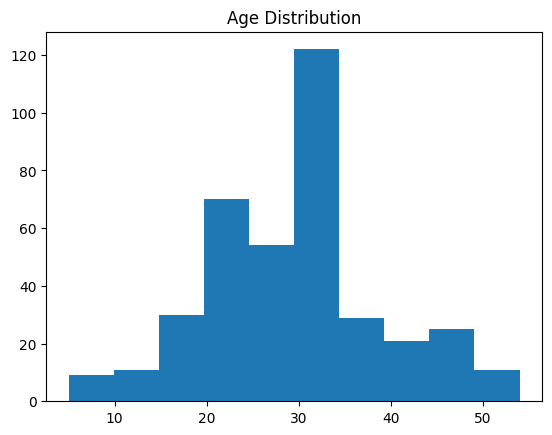

In [40]:
plt.hist(df["Age"])
plt.title("Age Distribution")
plt.show()

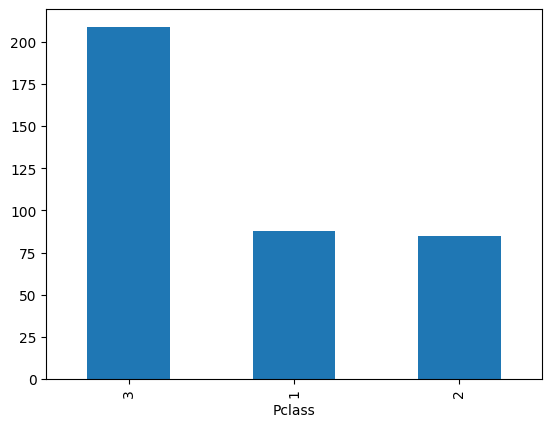

In [41]:
df["Pclass"].value_counts().plot(kind="bar")
plt.show()

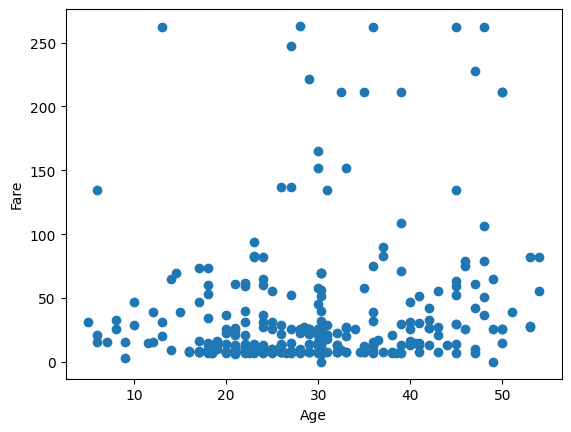

In [42]:
plt.scatter(df["Age"], df["Fare"])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

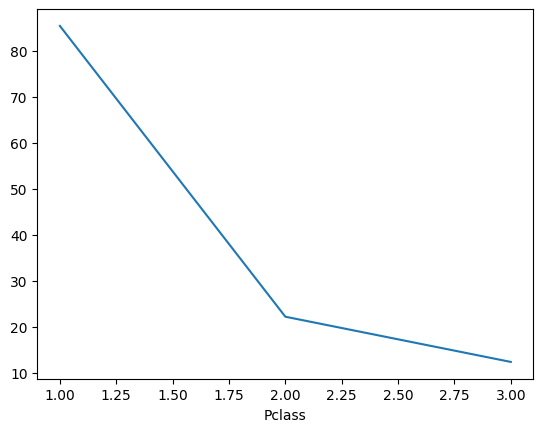

In [43]:
df.groupby("Pclass")["Fare"].mean().plot()
plt.show()

In [45]:
# correlation
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.039912,-0.044745,0.032206,0.007433,0.040765,0.015917
Survived,-0.039912,1.000000,-0.094345,-0.008387,0.083575,0.144870,0.200658
Pclass,-0.044745,-0.094345,1.000000,-0.355237,0.027766,0.032441,-0.592858
Age,0.032206,-0.008387,-0.355237,1.000000,-0.136567,-0.009692,0.207160
SibSp,0.007433,0.083575,0.027766,-0.136567,1.000000,0.313064,0.194214
Parch,0.040765,0.144870,0.032441,-0.009692,0.313064,1.000000,0.213463
Fare,0.015917,0.200658,-0.592858,0.207160,0.194214,0.213463,1.000000


In [46]:
# saving the cleaned data
df.to_csv("Titanic_Cleaned.csv", index=False)